# Libs

In [1]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset

import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

/tmp/ipython-input-3462211136.py:13: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

# Data

## Loaders

In [3]:
transform = T.Compose([
                       T.ToTensor(),
                       T.Normalize(mean = [0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = torchvision.datasets.STL10(root = './data',
                                           download = True,
                                           split = 'train',
                                           transform = transform)

test_dataset = torchvision.datasets.STL10(root = './data',
                                          download = True,
                                          split = 'test',
                                          transform = transform)

# transform to dataloaders
batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True, drop_last = True)
test_dataloader = DataLoader(test_dataset, batch_size = 256)

100%|██████████| 2.64G/2.64G [05:24<00:00, 8.13MB/s]


In [172]:
print('Data shapes (train/test):')
print(train_dataset.data.shape)
print(test_dataset.data.shape)

# and the range of pixel intensity values
print('\nData value range:')
print((np.min(train_dataset.data), np.max(train_dataset.data)))

# the unique categories
print('\nData categories:')
print(train_dataset.classes)

Data shapes (train/test):
(5000, 3, 96, 96)
(8000, 3, 96, 96)

Data value range:
(np.uint8(0), np.uint8(255))

Data categories:
['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [173]:
X, y = next(iter(train_dataloader))

print('Data shapes (train/test)')
print(X.data.shape)

print('\nData value range:')
print((torch.min(X.data), torch.max(X.data)))

Data shapes (train/test)
torch.Size([32, 3, 96, 96])

Data value range:
(tensor(-2.1179), tensor(2.6400))


## Hist

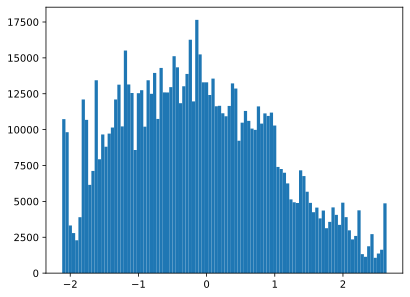

In [174]:
# histogram of data
plt.hist(X.data.numpy().flatten(), 100)
plt.show()

## Viz

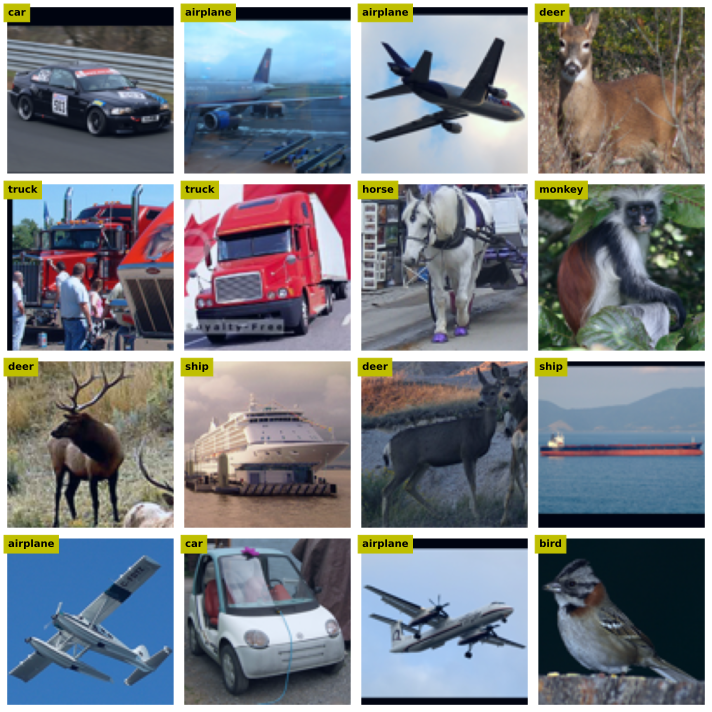

In [175]:
fig, axs = plt.subplots(4,4,figsize = (10,10))

for (i, ax) in enumerate(axs.flatten()):

  # extract that image (need to transpose it back to 32x32x3)
  pic = X.data[i].numpy().transpose((1,2,0))
  pic = pic-np.min(pic) # undo normalization
  pic = pic/np.max(pic)

  # labels
  label = train_dataset.classes[y[i]]

  # show
  ax.imshow(pic)
  ax.text(0,0,label,ha='left',va='top',fontweight='bold', color='k',backgroundcolor='y')
  ax.axis('off')

plt.tight_layout()
plt.show()

# Import and Inspect Resnet

In [176]:
resnet = torchvision.models.resnet18(pretrained = True)
resnet

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [177]:
from torchsummary import summary
summary(resnet.to(device), (3,96,96))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 48, 48]           9,408
       BatchNorm2d-2           [-1, 64, 48, 48]             128
              ReLU-3           [-1, 64, 48, 48]               0
         MaxPool2d-4           [-1, 64, 24, 24]               0
            Conv2d-5           [-1, 64, 24, 24]          36,864
       BatchNorm2d-6           [-1, 64, 24, 24]             128
              ReLU-7           [-1, 64, 24, 24]               0
            Conv2d-8           [-1, 64, 24, 24]          36,864
       BatchNorm2d-9           [-1, 64, 24, 24]             128
             ReLU-10           [-1, 64, 24, 24]               0
       BasicBlock-11           [-1, 64, 24, 24]               0
           Conv2d-12           [-1, 64, 24, 24]          36,864
      BatchNorm2d-13           [-1, 64, 24, 24]             128
             ReLU-14           [-1, 64,

## Freeze all Layers

In [178]:
for p in resnet.parameters():
  p.requires_grad = False

# or in-line
# p.requires_grad_(False)

## Adjust Final Layer

Resnet was trained on 1000 images, meaning we have 1000 classes, out-neurons on last layer. We need to change it to 10 out-neurons.

In [179]:
resnet.fc = nn.Linear(512, 10)
resnet.fc

Linear(in_features=512, out_features=10, bias=True)

## Unfreeze last layer

In [180]:
resnet.fc.requires_grad = True

## Model to GPU

In [181]:
resnet.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Loss and Optim

In [182]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(resnet.fc.parameters(), lr = 1e-4, weight_decay=1e-4)

## Test Model

In [183]:
def testModel(net):

  X, y = next(iter(test_dataloader))
  X = X.to(device)
  y = y.to(device)
  net.to(device)
  y_hat = net(X)

  # check sizes of model outputs and target variable
  print(' ')
  print(y_hat.shape)
  print(y.shape)

  # now let's compute the loss
  loss = loss_fn(y_hat, y)
  print(' ')
  print('Loss:')
  print(loss)

  matches = (torch.argmax(y_hat, axis = 1) == y).float()
  accuracy = 100 * torch.mean(matches)
  print(' ')
  print('Accuracy:')
  print(accuracy.item(),'%')

testModel(resnet)

 
torch.Size([256, 10])
torch.Size([256])
 
Loss:
tensor(2.6096, device='cuda:0', grad_fn=<NllLossBackward0>)
 
Accuracy:
9.375 %


Without fine-tuning our model achieves 80% of accuracy. Let's see how it will perform after finetuning for 10 epochs.

# Feature Extraction (fc)

We freezed whole backbone and left trainable only fc layer to adjust to our data, i.e. we're not doing fine-tuning but feature extraction.

In [184]:
def ModelTrain(net, verbose, epochs, patience=4):

  losses = torch.zeros(epochs)
  train_acc = []
  test_acc = []

  best_acc = 0.0
  epochs_no_improve = 0

  net.to(device)

  for epoch in range(epochs):
    net.train()
    batch_acc = []
    batch_loss = []

    for X,y in train_dataloader:
      X = X.to(device)
      y = y.to(device)

      y_hat = net(X)
      loss = loss_fn(y_hat, y)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_loss.append(loss.item())

      matches = (torch.argmax(y_hat, axis=1) == y).float()
      accuracy = 100 * torch.mean(matches)
      batch_acc.append(accuracy)

    train_acc.append(torch.mean(torch.stack(batch_acc)).item())
    losses[epoch] = np.mean(batch_loss)

    # --- TEST ---
    net.eval()
    X, y = next(iter(test_dataloader))
    X = X.to(device)
    y = y.to(device)

    with torch.no_grad():
      y_hat = net(X)

    current_test_acc = 100 * torch.mean(
        (torch.argmax(y_hat, axis=1) == y).float()
    ).item()

    test_acc.append(current_test_acc)

    # --- EARLY STOP ---
    if current_test_acc > best_acc:
      best_acc = current_test_acc
      epochs_no_improve = 0
    else:
      epochs_no_improve += 1

    if verbose:
      print(f'Epoch: {epoch} | Train Acc: {train_acc[-1]:.2f} | Test Acc: {current_test_acc:.2f}')

    if epochs_no_improve >= patience:
      print(f'\nEarly stopping at epoch {epoch}')
      break

  return train_acc, test_acc, losses[:len(train_acc)], net


## Train

In [185]:
train_acc, test_acc, losses, net = ModelTrain(net = resnet,
                                              verbose = True,
                                              epochs = 15)

Epoch: 0 | Train Acc: 27.78 | Test Acc: 37.50
Epoch: 1 | Train Acc: 54.13 | Test Acc: 55.86
Epoch: 2 | Train Acc: 64.30 | Test Acc: 66.02
Epoch: 3 | Train Acc: 69.33 | Test Acc: 67.19
Epoch: 4 | Train Acc: 71.92 | Test Acc: 68.75
Epoch: 5 | Train Acc: 73.24 | Test Acc: 71.48
Epoch: 6 | Train Acc: 74.82 | Test Acc: 74.22
Epoch: 7 | Train Acc: 74.86 | Test Acc: 74.22
Epoch: 8 | Train Acc: 76.38 | Test Acc: 74.61
Epoch: 9 | Train Acc: 76.64 | Test Acc: 73.05
Epoch: 10 | Train Acc: 77.26 | Test Acc: 74.22
Epoch: 11 | Train Acc: 77.70 | Test Acc: 75.00
Epoch: 12 | Train Acc: 77.28 | Test Acc: 75.39
Epoch: 13 | Train Acc: 78.47 | Test Acc: 77.73
Epoch: 14 | Train Acc: 78.81 | Test Acc: 76.56


## Test

In [186]:
testModel(net)

 
torch.Size([256, 10])
torch.Size([256])
 
Loss:
tensor(0.7462, device='cuda:0', grad_fn=<NllLossBackward0>)
 
Accuracy:
76.5625 %


## Plots

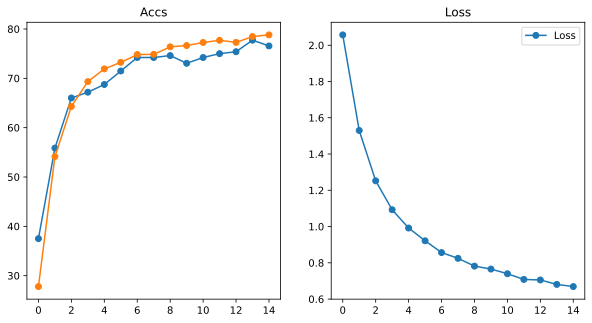

In [187]:
fig, axs = plt.subplots(1,2, figsize = (10,5))

axs[0].plot(test_acc, '-o', label = 'Test Acc')
axs[0].plot(train_acc, '-o', label = 'Train Acc')
axs[0].set_title('Accs')

axs[1].plot(losses, '-o', label = 'Loss')
axs[1].set_title('Loss')

plt.legend()
plt.show()

## Sumup

Feature extraction didn't go well. Our model didn't improve. 76% is still good for expected 10% having no training. Let's unfreeze the layer4 and train again making it actual fine-tuning.

# Fine-Tuning (Layer4)

## Restart and Setup Model

In [188]:
resnet = torchvision.models.resnet18(pretrained = True)

for p in resnet.parameters():
  p.requires_grad = False

for p in resnet.layer4.parameters():
  p.requires_grad = True

resnet.fc.requires_grad = True

Since fc is random and we're far away for minima we need to make bigger steps so lr should be bigger. For layer4 we already have pretrained weights, i.e. we can allow ourself for smaller steps and lr can be equal to 1e-4.

## Optimizer

In [189]:
import torch.optim as optim

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.AdamW([
    {"params": resnet.fc.parameters(),     "lr": 1e-3},
    {"params": resnet.layer4.parameters(), "lr": 1e-4},
], weight_decay=1e-4)

## Train

In [190]:
train_acc, test_acc, losses, net = ModelTrain(net = resnet,
                                              verbose = True,
                                              epochs = 15)

Epoch: 0 | Train Acc: 57.85 | Test Acc: 81.25
Epoch: 1 | Train Acc: 88.18 | Test Acc: 83.59
Epoch: 2 | Train Acc: 94.53 | Test Acc: 82.81
Epoch: 3 | Train Acc: 97.40 | Test Acc: 83.98
Epoch: 4 | Train Acc: 98.22 | Test Acc: 85.94
Epoch: 5 | Train Acc: 99.08 | Test Acc: 85.94
Epoch: 6 | Train Acc: 99.26 | Test Acc: 85.55
Epoch: 7 | Train Acc: 99.54 | Test Acc: 85.94
Epoch: 8 | Train Acc: 99.62 | Test Acc: 86.33
Epoch: 9 | Train Acc: 99.64 | Test Acc: 85.16
Epoch: 10 | Train Acc: 99.70 | Test Acc: 85.16
Epoch: 11 | Train Acc: 99.42 | Test Acc: 84.38
Epoch: 12 | Train Acc: 99.50 | Test Acc: 84.77

Early stopping at epoch 12


## Test

In [191]:
testModel(resnet)

 
torch.Size([256, 1000])
torch.Size([256])
 
Loss:
tensor(0.7981, device='cuda:0', grad_fn=<NllLossBackward0>)
 
Accuracy:
84.765625 %


## Plots

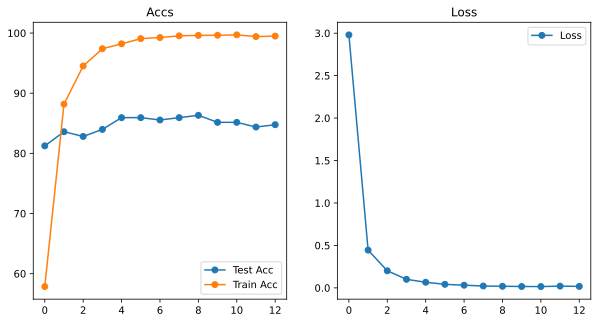

In [192]:
fig, axs = plt.subplots(1,2, figsize = (10,5))

axs[0].plot(test_acc, '-o', label = 'Test Acc')
axs[0].plot(train_acc, '-o', label = 'Train Acc')
axs[0].set_title('Accs')
axs[0].legend()
axs[1].plot(losses, '-o', label = 'Loss')
axs[1].set_title('Loss')
axs[1].legend()
plt.show()

## Sumup

By unfreezing the entire Layer4 block, we increased the model’s capacity to adapt high-level representations to the target dataset. This resulted in an almost 10% improvement in training accuracy compared to pure feature extraction, indicating that the model can better fit the training data when minimal fine-tuning is applied.

However, this improvement does not translate into better generalization. Layer4 contains high-level, semantically rich features that are already well-optimized for generic visual recognition. When trained on a relatively small dataset, updating these parameters introduces high variance and leads to memorization of training examples rather than learning more robust representations. As a result, the training accuracy continues to increase while test accuracy saturates, producing a clear overfitting gap.

In this data-limited regime, freezing the backbone acts as an implicit regularizer, whereas fine-tuning Layer4 increases model capacity beyond what the dataset can reliably support.

# Fine-Tuning (whole Backbone)

## Restart and Setup Model

Since we got some improvement after unfreezing layer4, let's test the whole model so after unfreezing whole backbone and fune-tune it on additional 15 epochs.

In [193]:
resnet = torchvision.models.resnet18(pretrained = True)

for p in resnet.parameters():
  p.requires_grad = True

## Optimizer

In [194]:
import torch.optim as optim

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.AdamW([
    {"params": resnet.fc.parameters(),     "lr": 1e-3},
    {"params": resnet.layer4.parameters(), "lr": 1e-4},
    {"params": resnet.layer3.parameters(), "lr": 5e-5},
    {"params": resnet.layer2.parameters(), "lr": 1e-5},
    {"params": resnet.layer1.parameters(), "lr": 1e-5},
], weight_decay=1e-4)

## Train

In [195]:
train_acc, test_acc, losses, net = ModelTrain(net = resnet,
                                              verbose = True,
                                              epochs = 15)

Epoch: 0 | Train Acc: 67.05 | Test Acc: 83.20
Epoch: 1 | Train Acc: 92.89 | Test Acc: 84.77
Epoch: 2 | Train Acc: 97.70 | Test Acc: 83.59
Epoch: 3 | Train Acc: 98.86 | Test Acc: 84.77
Epoch: 4 | Train Acc: 99.22 | Test Acc: 86.33
Epoch: 5 | Train Acc: 99.56 | Test Acc: 86.33
Epoch: 6 | Train Acc: 99.60 | Test Acc: 84.77
Epoch: 7 | Train Acc: 99.38 | Test Acc: 88.67
Epoch: 8 | Train Acc: 99.46 | Test Acc: 85.94
Epoch: 9 | Train Acc: 99.28 | Test Acc: 85.55
Epoch: 10 | Train Acc: 99.50 | Test Acc: 85.16
Epoch: 11 | Train Acc: 98.50 | Test Acc: 84.77

Early stopping at epoch 11


## Test

In [196]:
testModel(resnet)

 
torch.Size([256, 1000])
torch.Size([256])
 
Loss:
tensor(0.8660, device='cuda:0', grad_fn=<NllLossBackward0>)
 
Accuracy:
84.765625 %


## Plots

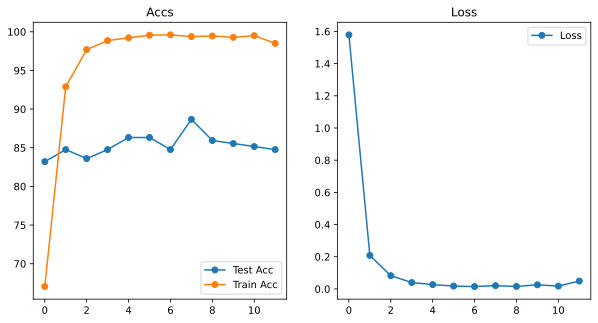

In [197]:
fig, axs = plt.subplots(1,2, figsize = (10,5))

axs[0].plot(test_acc, '-o', label = 'Test Acc')
axs[0].plot(train_acc, '-o', label = 'Train Acc')
axs[0].set_title('Accs')
axs[0].legend()
axs[1].plot(losses, '-o', label = 'Loss')
axs[1].set_title('Loss')
axs[1].legend()
plt.show()

## Sumup

We have similar situation as in Fine-Tuning with just layer4 activated, i.e. there is no rational cause to activate full backbone, instead it's best to activate only layer4 for finetuning.

## Visualize

In [198]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# weź jeden batch
X, y = next(iter(test_dataloader))
X = X.to(device)
y = y.to(device)

# predykcje
resnet.eval()
with torch.no_grad():
    logits = resnet(X)
    preds = torch.argmax(logits, dim=1)

# do CPU
X = X.cpu()
y = y.cpu()
preds = preds.cpu()

# denormalizacja (jeśli używałeś ImageNet mean/std)
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

classes = test_dataset.classes

fig, axs = plt.subplots(6, 7, figsize=(14, 12))
axs = axs.flatten()

for i, ax in enumerate(axs):
    img = X[i].numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)

    true_lbl = classes[y[i]]
    pred_lbl = classes[preds[i]]

    ax.imshow(img)
    ax.set_title(f"T: {true_lbl}\nP: {pred_lbl}", fontsize=9)

    # kolor ramki
    color = "green" if y[i] == preds[i] else "red"
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


# VGG-16 Net Comparison

In [199]:
vgg = torchvision.models.vgg16(pretrained = True)
vgg

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

## Freeze all Layers

In [200]:
for p in vgg.parameters():
  p.requires_grad = False

## Adjust Final Layer

In [201]:
vgg.classifier[6] = nn.Linear(4096, 10)

## Unfreeze Last Layer

In [202]:
vgg.classifier[6].requires_grad = True

## Model to GPU

In [203]:
vgg.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

## Loss and Optim

In [205]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(vgg.classifier[6].parameters(), lr = 1e-4, weight_decay=1e-4)

## Test Raw Model

In [206]:
testModel(vgg)

 
torch.Size([256, 10])
torch.Size([256])
 
Loss:
tensor(2.6906, device='cuda:0', grad_fn=<NllLossBackward0>)
 
Accuracy:
9.375 %


## Train

In [207]:
train_acc, test_acc, losses, net = ModelTrain(net = vgg,
                                              verbose = True,
                                              epochs = 15)

Epoch: 0 | Train Acc: 67.27 | Test Acc: 91.80
Epoch: 1 | Train Acc: 87.66 | Test Acc: 91.41
Epoch: 2 | Train Acc: 89.72 | Test Acc: 92.19
Epoch: 3 | Train Acc: 91.01 | Test Acc: 91.02
Epoch: 4 | Train Acc: 91.61 | Test Acc: 92.97
Epoch: 5 | Train Acc: 91.83 | Test Acc: 92.97
Epoch: 6 | Train Acc: 92.47 | Test Acc: 92.97
Epoch: 7 | Train Acc: 93.29 | Test Acc: 92.58
Epoch: 8 | Train Acc: 93.45 | Test Acc: 92.58

Early stopping at epoch 8


## Test

In [208]:
testModel(vgg)

 
torch.Size([256, 10])
torch.Size([256])
 
Loss:
tensor(0.2403, device='cuda:0', grad_fn=<NllLossBackward0>)
 
Accuracy:
92.578125 %


## Plots

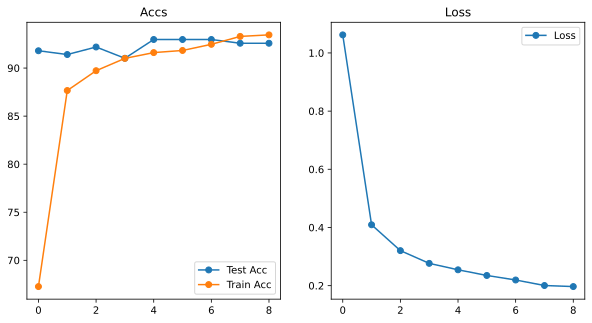

In [209]:
fig, axs = plt.subplots(1,2, figsize = (10,5))

axs[0].plot(test_acc, '-o', label = 'Test Acc')
axs[0].plot(train_acc, '-o', label = 'Train Acc')
axs[0].set_title('Accs')
axs[0].legend()
axs[1].plot(losses, '-o', label = 'Loss')
axs[1].set_title('Loss')
axs[1].legend()
plt.show()

# Conclusion

The observed behavior across experiments can be explained by the interaction between dataset size, model capacity, and the role of pretrained representations.

ResNet – Feature Extraction (Frozen Backbone, ~75% Test Accuracy)
When the entire ResNet backbone is frozen and only the classification head is trained, the model relies exclusively on pretrained ImageNet features. These features are robust and general-purpose, but the ResNet classification head is relatively shallow and has limited capacity. As a result, while the model generalizes stably, its expressive power is constrained, leading to a moderate test accuracy of around 75%.

ResNet – Minimal Fine-Tuning (Layer4 + FC Active, ~85% Train, Overfitting)
Unfreezing Layer4 significantly increases the number of trainable parameters and allows the model to adapt high-level semantic features to the training set. This results in a strong improvement in training accuracy (≈85%). However, because the dataset is relatively small, the additional capacity leads to high variance: the model begins to memorize training examples rather than learning more generalizable representations. Consequently, test accuracy saturates and a clear train–test gap appears, indicating overfitting.

ResNet – Full Fine-Tuning (Entire Backbone Active, Same Overfitting Regime)
Activating the entire backbone further increases model capacity but does not improve test performance beyond what is achieved by fine-tuning Layer4 alone. The model remains in a data-limited regime: additional trainable parameters only accelerate memorization without providing new information. As a result, the overfitting behavior is similar to the minimal fine-tuning case, with no gains in generalization.

VGG – Feature Extraction (Only Final Layer Active, ~92% Test Accuracy)
In contrast, VGG achieves the best performance when used purely as a feature extractor with only the final classification layer trained. This is due to VGG’s very large and expressive classifier (two 4096-unit fully connected layers), which is capable of linearly separating pretrained features extremely well. The frozen VGG backbone provides highly discriminative representations, and the powerful classifier adapts efficiently without modifying the backbone. This setup achieves strong generalization and reaches ~92% test accuracy within a few epochs, without entering an overfitting regime.

ResNet benefits less from feature extraction due to its relatively small classification head, while fine-tuning introduces excessive variance on a small dataset. VGG, on the other hand, pairs strong pretrained features with a high-capacity classifier, making feature extraction the optimal strategy. These results highlight that the effectiveness of fine-tuning depends not only on dataset size but also on the architectural balance between backbone representations and classifier capacity.